In [1]:
import mne
from moabb.datasets import GuttmannFlury2025_MI

/opt/miniconda3/envs/mne_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
dataset = GuttmannFlury2025_MI()
data = dataset.get_data(subjects=[2])

Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('left_hand'), np.str_('right_hand')]


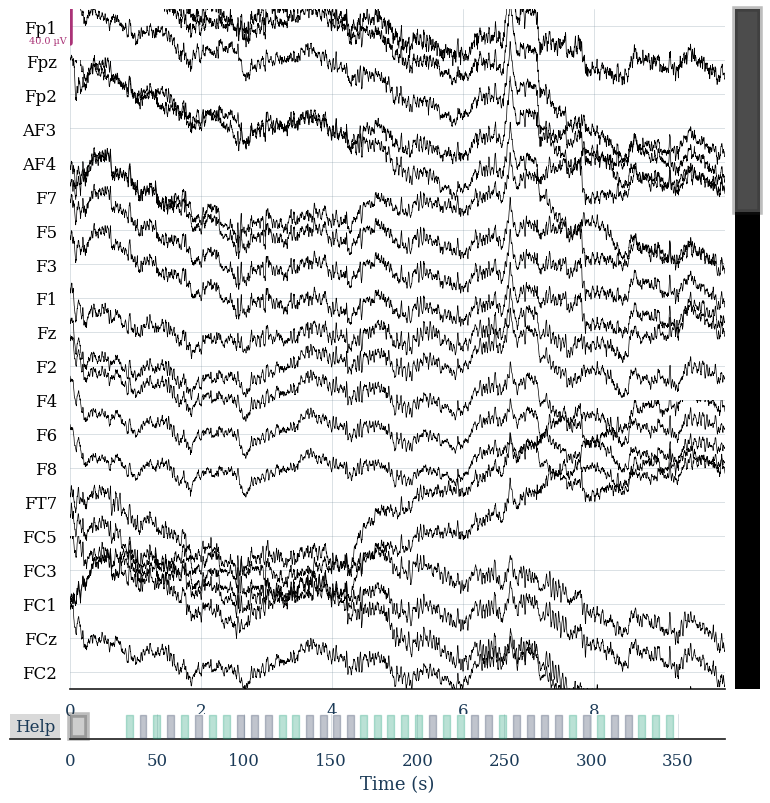

<Info | 10 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, AF3, AF4, F7, F5, F3, F1, Fz, F2, F4, F6, F8, ...
 chs: 66 EEG, 1 Stimulus
 custom_ref_applied: False
 dig: 0 items
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 500.0 Hz
 meas_date: 2018-09-01 17:56:55 UTC
 nchan: 67
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, hand: 1, height: 1.76>
>


In [23]:
# avoid having two plots inline
%matplotlib inline


raw = data[2]["0"]["0"]
raw.plot()
print(raw.info)

In [24]:
# have a look at annotations
print(raw.annotations)
df_annot = raw.annotations.to_data_frame()
print(df_annot)

<Annotations | 40 segments: left_hand (20), right_hand (20)>
                     onset  duration description
0  2018-09-01 17:57:27.164       4.0  right_hand
1  2018-09-01 17:57:35.030       4.0   left_hand
2  2018-09-01 17:57:42.931       4.0  right_hand
3  2018-09-01 17:57:50.981       4.0   left_hand
4  2018-09-01 17:57:58.830       4.0  right_hand
5  2018-09-01 17:58:06.814       4.0   left_hand
6  2018-09-01 17:58:14.847       4.0  right_hand
7  2018-09-01 17:58:22.980       4.0  right_hand
8  2018-09-01 17:58:31.113       4.0   left_hand
9  2018-09-01 17:58:39.313       4.0   left_hand
10 2018-09-01 17:58:47.297       4.0   left_hand
11 2018-09-01 17:58:55.046       4.0  right_hand
12 2018-09-01 17:59:02.780       4.0  right_hand
13 2018-09-01 17:59:10.979       4.0   left_hand
14 2018-09-01 17:59:18.746       4.0   left_hand
15 2018-09-01 17:59:26.562       4.0   left_hand
16 2018-09-01 17:59:34.412       4.0   left_hand
17 2018-09-01 17:59:42.129       4.0  right_hand
18 2018-

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 6601 samples (6.601 s)



EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


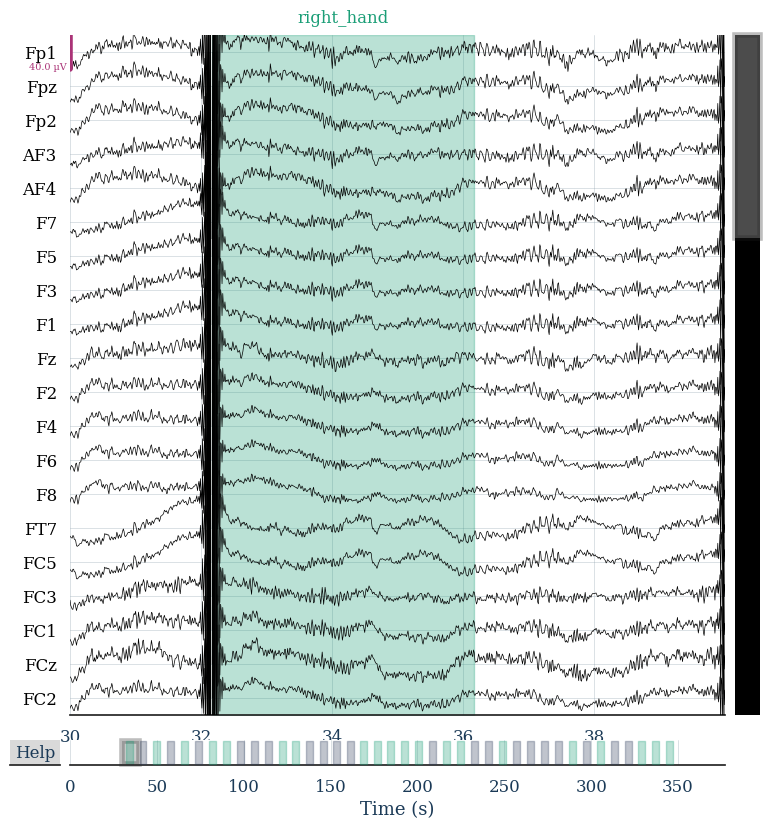

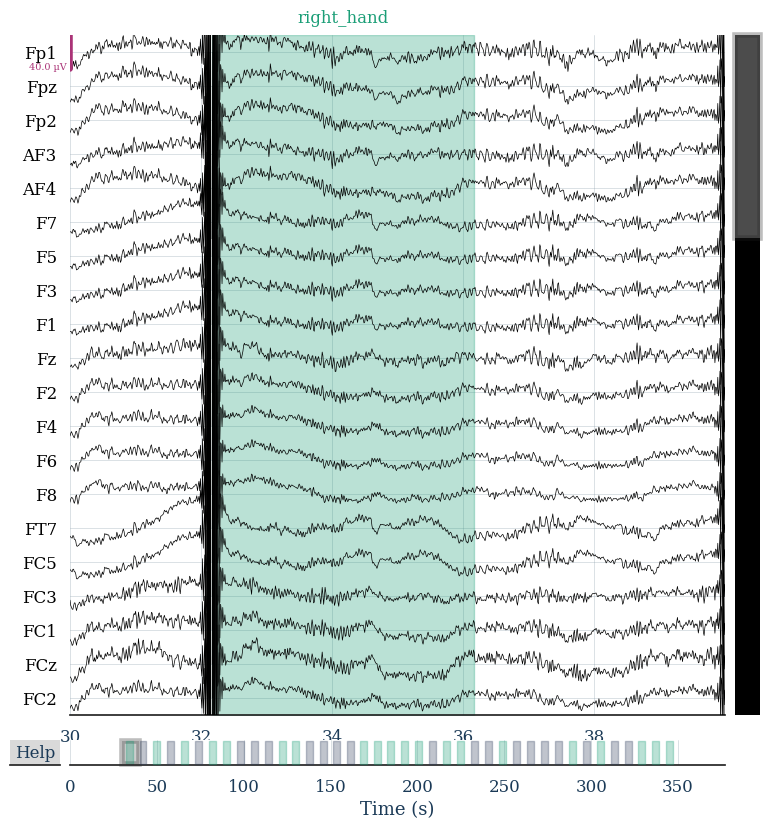

In [26]:
# 1. Minimalist Filtering
# we use l_freq=0.5 to keep it 'raw' but stable
# we use h_freq=None if you want absolute high-freqs, 
# but 45.0 is safer for ML models.
raw.filter(l_freq=0.5, h_freq=45.0, fir_design='firwin', phase='zero')

# 2. Notch Filter (Optional but recommended for 'Raw' look)
# This removes exactly 50Hz (or 60Hz) without touching other frequencies
# raw.notch_filter(freqs=[50.0], fir_design='firwin')

# 3. Re-referencing (The most important 'minimal' step)
# This subtracts the 'average' noise from all channels.
# It doesn't change the frequency, just cleans the spatial map.
raw.set_eeg_reference('average', projection=False)

# plot from time 0 to 10 seconds 
%matplotlib inline
raw.plot(start=30, duration=10)
# raw.plot(start=42, duration=2)